### Perform Clustering

In [1]:
# Imports
import numpy as np
import os, sys
import matplotlib.pyplot as plt

if "__file__" in globals():
    script_dir = os.path.dirname(os.path.abspath(__file__))
else:
    script_dir = os.getcwd()

utils_dir = os.path.abspath(os.path.join(script_dir, "..", "..", "..", "Utils"))
output_dir = os.path.abspath(os.path.join(script_dir, "..", "Outputs"))

sys.path.append(utils_dir)
from clustering import Cluster
from yaml_processor import load_config, save_config
from data_processing import load_dataset, save_dataset, parameter_plot
from sensor_processing import sensor_processing

config_file = os.path.abspath(os.path.join(script_dir, "..", "configuration.yaml"))
config_global = load_config(config_file)

##### Initialization

In [2]:
# Minimum number of data points in each cluster
min_data_per_cluster = 16

In [4]:
dataset_path = os.path.join(output_dir, "datasets")
FS_train, param_train, ft_train, disp_norm, vel_norm, ft_norm = load_dataset(os.path.join(dataset_path, "Train"))
FS_val, param_val, ft_val, _, _, _ = load_dataset(os.path.join(dataset_path, "Val"), disp_norm, vel_norm, ft_norm)
FS_test, param_test, ft_test, _, _, _ = load_dataset(os.path.join(dataset_path, "Test"), disp_norm, vel_norm, ft_norm)

In [5]:
# Apply Sensor Placement
sp = sensor_processing(FS_train[:, 1], config_global)
A_Mat, C_Mat, pinv_Theta, sensor_placement = sp.load(output_dir)
RS_train, RS_val, RS_test = sp.apply_sensors(FS_train, FS_val, FS_test)

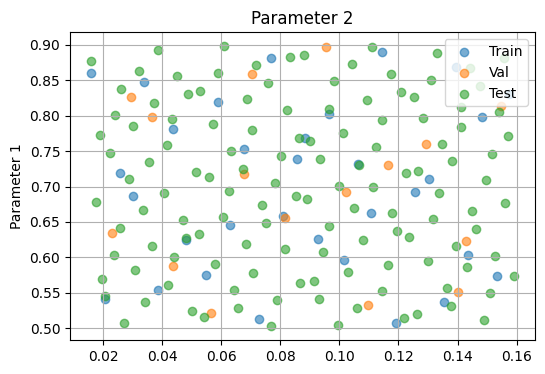

In [6]:
parameter_plot(param_train, param_val, param_test)

Perform Clustering

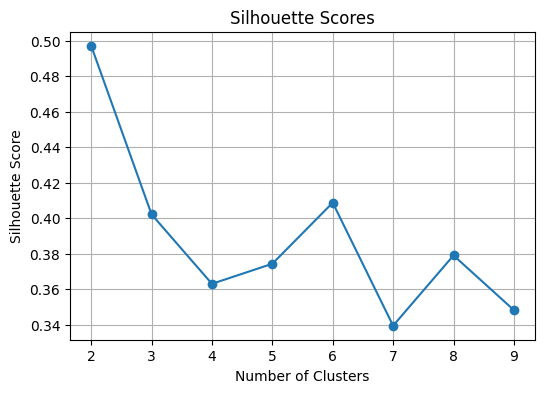

k=2, silhouette=0.497
k=3, silhouette=0.402
k=4, silhouette=0.363
k=5, silhouette=0.374
k=6, silhouette=0.409
k=7, silhouette=0.340
k=8, silhouette=0.379
k=9, silhouette=0.348


In [8]:
clust = Cluster(RS_train[:, 1], param_train) # clustering using velocity data
sil_scores = clust.find_best_k_by_silhouette(k_range=range(2, 10))

Choose optimal number of clusters

In [7]:
n_clusters = 6

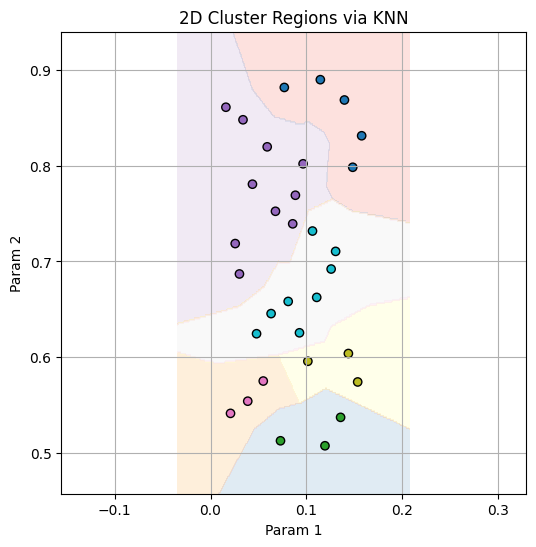

In [8]:
clust.find_clusters(n_clusters=n_clusters)
clust.plot_decision_regions()

##### Fill Missing Cluster Data

In [9]:
NLS_cl, param_cl, param_idx = clust.get_clustered_data()

In [14]:
for cluster in range(len(param_idx)):
    if len(param_idx[cluster]) < min_data_per_cluster:
        new_params = clust.generate_points_in_cluster(cluster_idx = cluster, n_samples=min_data_per_cluster-len(param_idx[cluster]), min_dist=0.02, oversample_factor=5)
        clust.params = np.concatenate([clust.params, new_params], axis=0)
        new_labels = np.ones([min_data_per_cluster-len(param_idx[cluster]), ])
        clust.cluster_labels = np.concatenate([clust.cluster_labels, new_labels], axis=0)

TypeError: list indices must be integers or slices, not numpy.float64

ValueError: 'c' argument has 32 elements, which is inconsistent with 'x' and 'y' with size 40.

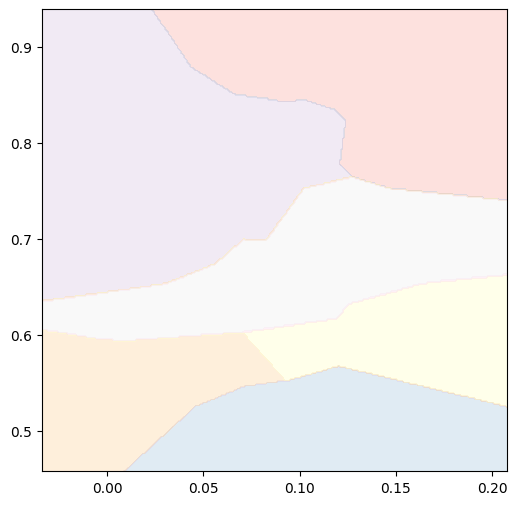

In [11]:
clust.plot_decision_regions()

In [12]:
clust.cluster_labels

array([3, 0, 5, 2, 5, 5, 4, 2, 5, 0, 1, 0, 3, 2, 5, 2, 2, 5, 4, 2, 1, 0,
       4, 2, 3, 0, 5, 2, 5, 2, 1, 2], dtype=int32)

In [24]:
test = np.array([1,2])

In [25]:
(test != None)

array([ True,  True])

In [19]:
config_global["data"]["n_clusters"] = n_clusters

AttributeError: type object 'type' has no attribute 'NoneType'

In [ ]:
save_config(config_file, config_global)